# SEC Filing Signals: From 10-Q Text to Alpha Factors

**Chapter 10: Text Feature Engineering**

**Docker image**: `ml4t-gpu`

**Section Reference**: See Section 10.5 for practitioner workflow and signal validation protocol

> **GPU recommended**: this notebook runs FinBERT and sentence-transformer
> inference over thousands of MD&A passages (no training). On a GPU the
> MAX_SYMBOLS=50 default lands in ~5 minutes; CPU is 5–10× slower. For GPU:
> ```bash
> docker compose run --rm ml4t-gpu python 10_text_feature_engineering/09_filing_text_signals.py
> ```


## Purpose

This notebook demonstrates how to construct alpha factors from SEC 10-Q filings.
Unlike headline-based signals (NB07), corporate filings provide dense, structured text
that reflects management's assessment of financial condition. We extract two complementary
signal types from MD&A sections:

1. **Sentiment signals** via FinBERT (directional bias in management language)
2. **Semantic change signals** via sentence-transformer embeddings (quarter-over-quarter narrative shifts)

The filing date provides a natural point-in-time anchor: the signal becomes available
when the SEC accepts the filing, not when the quarter ends.

## Learning Objectives

After completing this notebook, you will be able to:
- Load and explore SEC 10-Q MD&A text at scale
- Apply FinBERT sentiment scoring to long-form corporate text
- Compute document embeddings using sentence-transformers
- Construct a "narrative change" signal from sequential filing embeddings
- Join text signals to market data with point-in-time correctness
- Evaluate signal quality using IC, ICIR, and quintile analysis

## Prerequisites
- Section 10.5 of the chapter (alpha-factor evaluation, point-in-time joins).
- SEC 10-Q MD&A panel produced by `data/equities/fundamentals/filings_download.py`.

## Related Notebooks
- `04_bert_finetuning.py` / `06_finbert_cross_dataset.py` — FinBERT model details.
- `07_news_return_signals.py` — analogous workflow on headlines instead of filings.

In [1]:
"""SEC Filing Text Signals - FinBERT sentiment and embedding-based alpha factors."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch

from utils.paths import get_chapter_dir
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
# Production defaults (0 = all symbols; full dataset has 477 companies, 6770 filings)
# FinBERT scoring is sequential per-filing, so runtime scales linearly.
# 50 symbols (~750 filings) runs in ~5 minutes on GPU; set to 0 for full dataset.
SEED = 42
MAX_SYMBOLS = 50
MAX_FILINGS = 0
BATCH_SIZE = 8
MAX_TOKENS = 512
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
SENTIMENT_MODEL = "yiyanghkust/finbert-tone"

In [3]:
OUTPUT_DIR = get_chapter_dir(10) / "output" / "filing_signals"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility — set_global_seeds covers Python random / NumPy / Torch.
set_global_seeds(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name()}")

Device: cuda
GPU: NVIDIA GeForce RTX 3090


## 1. Load SEC 10-Q MD&A Data

The MD&A (Management's Discussion and Analysis) section is the most valuable narrative
section of quarterly filings. Unlike boilerplate Risk Factors that change slowly,
MD&A discusses current quarter performance and forward-looking outlook.

Data comes from our SEC EDGAR download script
(`data/equities/fundamentals/filings_download.py --form 10-Q --universe sp500`),
which extracts MD&A sections from S&P 500 10-Q filings (2017-2021).

In [4]:
from data import load_sp500_10q_mda

filings = load_sp500_10q_mda()

print(f"Loaded {len(filings):,} MD&A sections from {filings['symbol'].n_unique()} companies")
print(f"Date range: {filings['filing_date'].min()} to {filings['filing_date'].max()}")

if MAX_SYMBOLS > 0:
    top_symbols = (
        filings.group_by("symbol")
        .len()
        .sort("len", descending=True)
        .head(MAX_SYMBOLS)["symbol"]
        .to_list()
    )
    filings = filings.filter(pl.col("symbol").is_in(top_symbols))
    print(f"Filtered to {MAX_SYMBOLS} symbols: {len(filings):,} filings")

if MAX_FILINGS > 0 and len(filings) > MAX_FILINGS:
    filings = filings.sort(["filing_date", "symbol"]).head(MAX_FILINGS)
    print(f"Reduced to first {MAX_FILINGS} filings for test run")

# Compute MD&A word count from the canonical `text` column.
filings = filings.with_columns(pl.col("text").str.split(" ").list.len().alias("word_count"))

filings.head(5).select(["symbol", "filing_date", "period_end", "word_count"])

Loaded 6,770 MD&A sections from 477 companies
Date range: 2017-01-04 to 2021-12-22
Filtered to 50 symbols: 766 filings


symbol,filing_date,period_end,word_count
str,date,date,u32
"""AEE""",2017-05-05,2017-03-31,8986
"""AEE""",2017-08-04,2017-06-30,11308
"""AEE""",2017-11-03,2017-09-30,12928
"""AEE""",2018-05-09,2018-03-31,10119
"""AEE""",2018-08-08,2018-06-30,12495


MD&A word count statistics:
shape: (9, 2)
┌────────────┬──────────────┐
│ statistic  ┆ value        │
│ ---        ┆ ---          │
│ str        ┆ f64          │
╞════════════╪══════════════╡
│ count      ┆ 766.0        │
│ null_count ┆ 0.0          │
│ mean       ┆ 10158.275457 │
│ std        ┆ 7127.274687  │
│ min        ┆ 1643.0       │
│ 25%        ┆ 6008.0       │
│ 50%        ┆ 8541.0       │
│ 75%        ┆ 12016.0      │
│ max        ┆ 66208.0      │
└────────────┴──────────────┘


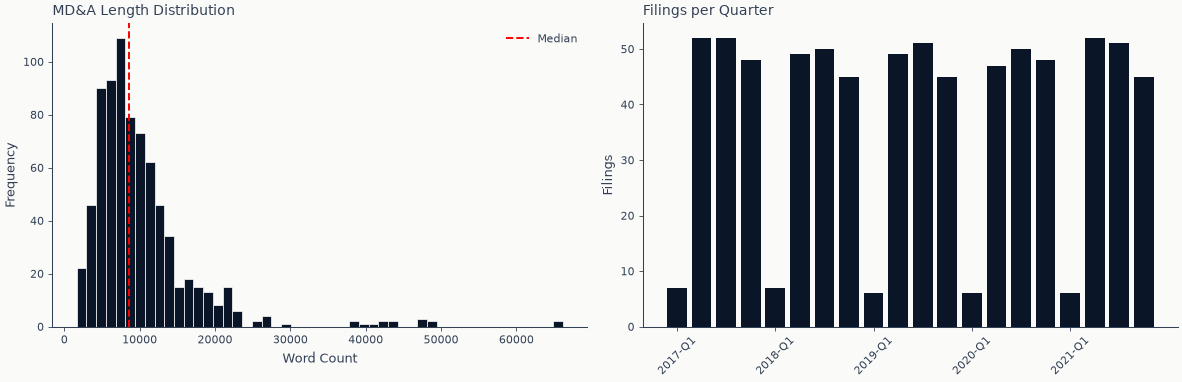

In [5]:
# Word count distribution
print("MD&A word count statistics:")
print(filings["word_count"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(filings["word_count"].to_numpy(), bins=50, edgecolor="white")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("MD&A Length Distribution")
axes[0].axvline(filings["word_count"].median(), color="red", linestyle="--", label="Median")
axes[0].legend()

# Filings per quarter
quarterly = (
    filings.with_columns(
        quarter=pl.col("filing_date").dt.year().cast(pl.String)
        + "-Q"
        + pl.col("filing_date").dt.quarter().cast(pl.String)
    )
    .group_by("quarter")
    .len()
    .sort("quarter")
)
axes[1].bar(range(len(quarterly)), quarterly["len"].to_numpy())
axes[1].set_xticks(range(0, len(quarterly), 4))
axes[1].set_xticklabels(quarterly["quarter"].to_list()[::4], rotation=45)
axes[1].set_ylabel("Filings")
axes[1].set_title("Filings per Quarter")

fig.tight_layout()
fig.show()

## 2. FinBERT Sentiment Scoring

FinBERT processes text at the sentence level (max 512 tokens). For long MD&A sections
(median ~6,000 words), we use a chunking strategy:

1. Split MD&A into sentences
2. Score each sentence with FinBERT (positive/negative/neutral probabilities)
3. Aggregate sentence scores to document-level sentiment

This mirrors how analysts read filings: extracting overall tone from many paragraphs.
The aggregation captures both the **average sentiment** (management tone) and
**sentiment dispersion** (mixed signals within the same filing).

In [6]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline, set_seed

set_seed(SEED)
print(f"Loading FinBERT: {SENTIMENT_MODEL}")
tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_MODEL)
model = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODEL)
model = model.to(device)
model.eval()

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=device,
    truncation=True,
    max_length=MAX_TOKENS,
    batch_size=BATCH_SIZE,
)
print("FinBERT loaded")

Loading FinBERT: yiyanghkust/finbert-tone


config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Device set to use cuda


FinBERT loaded


### Chunking Strategy

MD&A sections average ~6,000 words but FinBERT accepts only 512 tokens (~380 words).
We split into paragraphs and score each one, then aggregate.

In [7]:
def chunk_text(text: str, max_chars: int = 1500) -> list[str]:
    """Split text into chunks suitable for FinBERT (roughly 512 tokens each)."""
    paragraphs = [p.strip() for p in text.split("\n\n") if len(p.strip()) > 50]
    if not paragraphs:
        # Fall back to sentence splitting
        paragraphs = [s.strip() + "." for s in text.split(".") if len(s.strip()) > 30]

    chunks = []
    current = ""
    for para in paragraphs:
        if len(current) + len(para) > max_chars and current:
            chunks.append(current.strip())
            current = para
        else:
            current = current + "\n\n" + para if current else para

    if current.strip():
        chunks.append(current.strip())

    return chunks if chunks else [text[:max_chars]]

In [8]:
def score_document_sentiment(text: str) -> dict:
    """Score full MD&A document by aggregating chunk-level FinBERT predictions."""
    chunks = chunk_text(text)
    if not chunks:
        return {"sentiment_mean": 0.0, "sentiment_std": 0.0, "n_chunks": 0}

    # Score all chunks
    results = sentiment_pipeline(chunks)

    # Convert labels to numeric: positive=+1, neutral=0, negative=-1
    label_map = {"Positive": 1.0, "Neutral": 0.0, "Negative": -1.0}
    scores = []
    for r in results:
        label = r["label"]
        confidence = r["score"]
        numeric = label_map.get(label, 0.0) * confidence
        scores.append(numeric)

    scores_arr = np.array(scores)
    return {
        "sentiment_mean": float(scores_arr.mean()),
        "sentiment_std": float(scores_arr.std()) if len(scores_arr) > 1 else 0.0,
        "sentiment_pos_pct": float((scores_arr > 0).mean()),
        "sentiment_neg_pct": float((scores_arr < 0).mean()),
        "n_chunks": len(chunks),
    }

In [9]:
# Score all filings
print(f"Scoring {len(filings):,} MD&A sections with FinBERT...")
print("(This may take several minutes depending on GPU/CPU)")

sentiment_records = []
for i, row in enumerate(filings.iter_rows(named=True)):
    scores = score_document_sentiment(row["text"])
    scores["symbol"] = row["symbol"]
    scores["filing_date"] = row["filing_date"]
    sentiment_records.append(scores)

    if (i + 1) % 100 == 0 or (i + 1) == len(filings):
        print(f"  Scored {i + 1:,}/{len(filings):,} filings")

sentiment_df = pl.DataFrame(sentiment_records)
print(f"\nSentiment scoring complete: {len(sentiment_df):,} filings scored")
sentiment_df.head(5)

Scoring 766 MD&A sections with FinBERT...
(This may take several minutes depending on GPU/CPU)


model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Scored 100/766 filings


  Scored 200/766 filings


...

  Scored 500/766 filings


  Scored 600/766 filings


  Scored 700/766 filings


  Scored 766/766 filings

Sentiment scoring complete: 766 filings scored


sentiment_mean,sentiment_std,sentiment_pos_pct,sentiment_neg_pct,n_chunks,symbol,filing_date
f64,f64,f64,f64,i64,str,date
0.057667,0.398735,0.115385,0.057692,52,"""AEE""",2017-05-05
0.080763,0.411882,0.129032,0.048387,62,"""AEE""",2017-08-04
0.051018,0.455604,0.150685,0.09589,73,"""AEE""",2017-11-03
0.109907,0.438118,0.166667,0.05,60,"""AEE""",2018-05-09
0.0589,0.44085,0.150685,0.082192,73,"""AEE""",2018-08-08


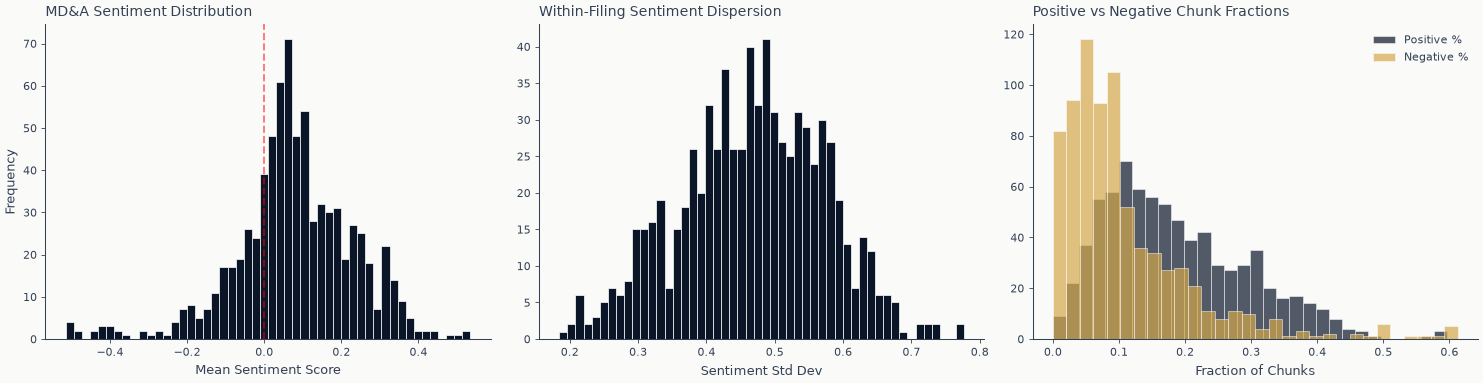

In [10]:
# Sentiment distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(sentiment_df["sentiment_mean"].to_numpy(), bins=50, edgecolor="white")
axes[0].set_xlabel("Mean Sentiment Score")
axes[0].set_ylabel("Frequency")
axes[0].set_title("MD&A Sentiment Distribution")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.5)

axes[1].hist(sentiment_df["sentiment_std"].to_numpy(), bins=50, edgecolor="white")
axes[1].set_xlabel("Sentiment Std Dev")
axes[1].set_title("Within-Filing Sentiment Dispersion")

axes[2].hist(
    sentiment_df["sentiment_pos_pct"].to_numpy(),
    bins=30,
    edgecolor="white",
    alpha=0.7,
    label="Positive %",
)
axes[2].hist(
    sentiment_df["sentiment_neg_pct"].to_numpy(),
    bins=30,
    edgecolor="white",
    alpha=0.7,
    label="Negative %",
)
axes[2].set_xlabel("Fraction of Chunks")
axes[2].set_title("Positive vs Negative Chunk Fractions")
axes[2].legend()

fig.tight_layout()
fig.show()

## 3. Document Embeddings and Narrative Change

Beyond sentiment polarity, we capture **semantic content** using sentence-transformer
embeddings. The key signal is **narrative change**: how much the MD&A text shifts
from one quarter to the next.

Intuition: a large semantic shift between consecutive filings suggests material
new information that the market may not have fully priced. This is analogous to
the "news surprise" factor in NB07, but applied to corporate disclosures.

In [11]:
from sentence_transformers import SentenceTransformer

print(f"Loading embedding model: {EMBEDDING_MODEL}")
embed_model = SentenceTransformer(EMBEDDING_MODEL, device=str(device))
print(f"Embedding dimension: {embed_model.get_sentence_embedding_dimension()}")

Loading embedding model: sentence-transformers/all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dimension: 384


### Document Embedding Strategy

Full MD&A texts are too long for a single embedding pass. We use **mean pooling
over chunk embeddings**: embed each paragraph/chunk, then average. This captures
the overall semantic content while respecting model token limits.

In [12]:
def embed_document(text: str, model: SentenceTransformer) -> np.ndarray:
    """Compute document embedding by mean-pooling chunk embeddings."""
    chunks = chunk_text(text, max_chars=1200)
    if not chunks:
        return np.zeros(model.get_sentence_embedding_dimension())

    chunk_embeddings = model.encode(chunks, show_progress_bar=False, batch_size=32)
    return chunk_embeddings.mean(axis=0)

In [13]:
# Compute embeddings for all filings
print(f"Computing embeddings for {len(filings):,} filings...")

embeddings = []
for i, row in enumerate(filings.iter_rows(named=True)):
    emb = embed_document(row["text"], embed_model)
    embeddings.append(emb)

    if (i + 1) % 100 == 0 or (i + 1) == len(filings):
        print(f"  Embedded {i + 1:,}/{len(filings):,} filings")

embeddings_array = np.stack(embeddings)
print(f"Embedding matrix: {embeddings_array.shape}")

Computing embeddings for 766 filings...


  Embedded 100/766 filings


  Embedded 200/766 filings


  Embedded 300/766 filings


  Embedded 400/766 filings


  Embedded 500/766 filings


  Embedded 600/766 filings


  Embedded 700/766 filings


  Embedded 766/766 filings
Embedding matrix: (766, 384)


In [14]:
# Compute quarter-over-quarter narrative change (cosine distance)
# For each filing, compare its embedding to the previous quarter's filing for the same company

# Sort by symbol and filing date
filing_order = (
    filings.select(["symbol", "filing_date"]).with_row_index("idx").sort(["symbol", "filing_date"])
)

narrative_changes = []
prev_emb_by_symbol = {}

for row in filing_order.iter_rows(named=True):
    idx = row["idx"]
    symbol = row["symbol"]
    emb = embeddings_array[idx]

    if symbol in prev_emb_by_symbol:
        prev_emb = prev_emb_by_symbol[symbol]
        # Cosine distance (0 = identical, 2 = opposite)
        cos_sim = np.dot(emb, prev_emb) / (np.linalg.norm(emb) * np.linalg.norm(prev_emb) + 1e-8)
        cos_dist = 1.0 - cos_sim
    else:
        cos_dist = None  # No previous quarter

    narrative_changes.append(
        {
            "symbol": symbol,
            "filing_date": row["filing_date"],
            "narrative_change": cos_dist,
        }
    )
    prev_emb_by_symbol[symbol] = emb

narrative_df = pl.DataFrame(narrative_changes)
print(
    f"Narrative change computed for {narrative_df.drop_nulls('narrative_change').height:,} filings"
)
print("  (first filing per company has no prior quarter for comparison)")

narrative_df.drop_nulls("narrative_change")["narrative_change"].describe()

Narrative change computed for 716 filings
  (first filing per company has no prior quarter for comparison)


statistic,value
str,f64
"""count""",716.0
"""null_count""",0.0
"""mean""",0.017853
"""std""",0.015828
"""min""",0.0
"""25%""",0.007205
"""50%""",0.013039
"""75%""",0.023264
"""max""",0.107054


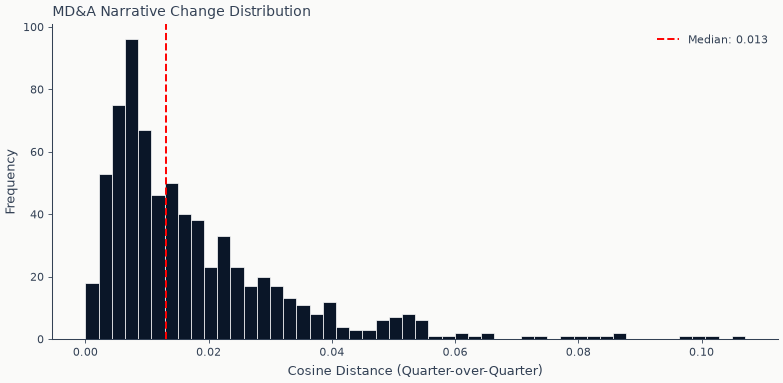

In [15]:
# Distribution of narrative change
valid_changes = narrative_df.drop_nulls("narrative_change")["narrative_change"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(valid_changes, bins=50, edgecolor="white")
ax.set_xlabel("Cosine Distance (Quarter-over-Quarter)")
ax.set_ylabel("Frequency")
ax.set_title("MD&A Narrative Change Distribution")
ax.axvline(
    np.median(valid_changes),
    color="red",
    linestyle="--",
    label=f"Median: {np.median(valid_changes):.3f}",
)
ax.legend()
fig.tight_layout()
fig.show()

## 4. Combine Signals and Join to Market Data

Two signal families are available:
- **Sentiment signals**: mean, std, positive/negative fractions
- **Narrative change**: cosine distance between consecutive filings

We join these to AlgoSeek S&P 500 daily prices using the **filing_date** as the
point-in-time anchor. The signal becomes investable on the filing date itself
(SEC filings are public immediately upon acceptance).

In [16]:
# Merge sentiment and narrative change
signals = sentiment_df.join(
    narrative_df.select(["symbol", "filing_date", "narrative_change"]),
    on=["symbol", "filing_date"],
    how="left",
)
print(f"Combined signals: {signals.shape}")
signals.head(5)

Combined signals: (782, 8)


sentiment_mean,sentiment_std,sentiment_pos_pct,sentiment_neg_pct,n_chunks,symbol,filing_date,narrative_change
f64,f64,f64,f64,i64,str,date,f64
0.057667,0.398735,0.115385,0.057692,52,"""AEE""",2017-05-05,null
0.080763,0.411882,0.129032,0.048387,62,"""AEE""",2017-08-04,0.006356
0.051018,0.455604,0.150685,0.09589,73,"""AEE""",2017-11-03,0.00282
0.109907,0.438118,0.166667,0.05,60,"""AEE""",2018-05-09,0.00599
0.0589,0.44085,0.150685,0.082192,73,"""AEE""",2018-08-08,0.003324


In [17]:
# Load S&P 500 daily prices
from data import load_sp500_daily_bars

prices = load_sp500_daily_bars()
print(f"Loaded {len(prices):,} price observations for {prices['symbol'].n_unique()} symbols")

# Compute forward returns: return from day t to day t+N
price_returns = (
    prices.sort(["symbol", "timestamp"])
    .with_columns(
        fwd_1d=(pl.col("close").shift(-1) / pl.col("close") - 1).over("symbol"),
        fwd_5d=(pl.col("close").shift(-5) / pl.col("close") - 1).over("symbol"),
        fwd_20d=(pl.col("close").shift(-20) / pl.col("close") - 1).over("symbol"),
    )
    .select(["symbol", "timestamp", "fwd_1d", "fwd_5d", "fwd_20d"])
)

Loaded 635,703 price observations for 638 symbols


In [18]:
# Join signals to prices using asof join
# Match each filing_date to the next trading day on or after that date
# This is PIT-correct: signal is available when the filing is accepted

# Add trade_date column to prices so we can track which day was matched
prices_with_trade_date = price_returns.with_columns(trade_date=pl.col("timestamp")).sort(
    ["symbol", "timestamp"]
)

# Prepare signals: rename filing_date -> timestamp for the asof join key
signals_for_join = signals.rename({"filing_date": "timestamp"}).sort(["symbol", "timestamp"])

# Asof join: for each signal date, find the nearest price date >= signal date
# strategy="forward" means: match the next trading day on or after the signal date
eval_df = (
    signals_for_join.join_asof(
        prices_with_trade_date,
        on="timestamp",
        by="symbol",
        strategy="forward",
    )
    .rename({"timestamp": "filing_date"})
    .drop_nulls(["fwd_5d"])
)

print(f"Evaluation dataset: {len(eval_df):,} observations ({eval_df['symbol'].n_unique()} symbols)")
print(f"Date range: {eval_df['filing_date'].min()} to {eval_df['filing_date'].max()}")

Evaluation dataset: 744 observations (50 symbols)
Date range: 2017-01-09 to 2021-12-02


## 5. Signal Evaluation: Information Coefficients

We evaluate each signal using rank Information Coefficients (IC): the Spearman
correlation between signal values and subsequent returns. A good alpha factor
should show consistent, positive IC over time.

The **IC** measures predictive power per cross-section (one date), while
**ICIR** (IC / std(IC)) measures consistency across dates.

In [19]:
from scipy.stats import spearmanr

signal_cols = [
    "sentiment_mean",
    "sentiment_std",
    "sentiment_pos_pct",
    "sentiment_neg_pct",
    "narrative_change",
]
return_cols = ["fwd_1d", "fwd_5d", "fwd_20d"]

We compute pooled Spearman ICs across all (filing, forward-return) pairs and
pair each pooled IC with a **cluster bootstrap** inference: resample whole
symbols (with replacement), recompute the pooled IC on each bootstrap
replicate, and report the 95% percentile interval and a two-sided bootstrap
p-value for the null IC=0. The cluster bootstrap requires a non-null cluster
id, so filings with a null `symbol` are dropped from `eval_df` before
computing both the point IC and the bootstrap; this shrinks `n_obs` per row
slightly versus the prior signal-only `drop_nulls` and is intentional.

Why a cluster bootstrap on symbols? The pooled sample places the same firm
at multiple quarterly filings into one correlation. Returns are also
overlapping for the 5-day and 20-day horizons. The i.i.d. t-stat formula
`t = r·sqrt((n-2)/(1-r²))` would therefore overstate significance. Cluster
bootstrap on symbols preserves the within-firm dependence between filings
and overlapping returns. Treat the headline ICs as **screening** values;
the chapter's headline inference framework uses HAC on cross-sectional IC
series with adequate breadth (see NB07, NB08).

In [20]:
# Compute pooled ICs and cluster-bootstrap inference (cluster = symbol).
print("Signal Evaluation: Pooled ICs with cluster bootstrap (cluster=symbol)")
print("=" * 70)

N_BOOT = 1000
# Single RNG shared across all (signal, horizon) iterations. Reproducibility
# of the table therefore depends on the iteration order of `signal_cols` ×
# `return_cols` — reorder either list and every subsequent pair gets a
# different bootstrap draw. If fewer than MIN_VALID_BOOT of N_BOOT replicates
# remain valid after NaN-drop, the percentile/p-value is suppressed (NaN) so
# unstable estimates from degenerate draws (e.g., a draw where one cluster
# dominates) do not leak into the table.
MIN_VALID_BOOT = 200
_boot_rng = np.random.default_rng(SEED)


def _pooled_spearman(sig_vals: np.ndarray, ret_vals: np.ndarray) -> float:
    """Pooled Spearman correlation, robust to constant-signal slices."""
    if len(sig_vals) < 5:
        return np.nan
    if np.std(sig_vals) == 0 or np.std(ret_vals) == 0:
        return np.nan
    return float(spearmanr(sig_vals, ret_vals)[0])


ic_results = []
for sig in signal_cols:
    for ret in return_cols:
        valid = eval_df.select(["symbol", sig, ret]).drop_nulls()
        if valid.height < 20:
            continue
        symbols = valid["symbol"].to_numpy()
        sig_vals = valid[sig].to_numpy()
        ret_vals = valid[ret].to_numpy()
        n = len(sig_vals)

        ic_point = _pooled_spearman(sig_vals, ret_vals)

        # Cluster bootstrap: resample whole symbols with replacement.
        unique_symbols = np.unique(symbols)
        idx_by_symbol = {s: np.where(symbols == s)[0] for s in unique_symbols}
        boot_ics = np.empty(N_BOOT)
        for b in range(N_BOOT):
            drawn = _boot_rng.choice(unique_symbols, size=len(unique_symbols), replace=True)
            indices = np.concatenate([idx_by_symbol[s] for s in drawn])
            boot_ics[b] = _pooled_spearman(sig_vals[indices], ret_vals[indices])
        boot_ics = boot_ics[~np.isnan(boot_ics)]

        if boot_ics.size >= MIN_VALID_BOOT:
            ci_lo = float(np.percentile(boot_ics, 2.5))
            ci_hi = float(np.percentile(boot_ics, 97.5))
            # Two-sided bootstrap p-value via percentile-method test inversion:
            # the smallest α such that the (1-α) bootstrap CI excludes zero.
            # Not a recentered-around-zero reflection test — for that, swap
            # in `mean(|boot - boot.mean()| >= |ic_point|)`.
            p_boot = 2.0 * min(
                float(np.mean(boot_ics <= 0.0)),
                float(np.mean(boot_ics >= 0.0)),
            )
        else:
            ci_lo = ci_hi = p_boot = np.nan

        ic_results.append(
            {
                "signal": sig,
                "horizon": ret,
                "ic": round(ic_point, 4) if not np.isnan(ic_point) else np.nan,
                "ci95_lo": round(ci_lo, 4) if not np.isnan(ci_lo) else np.nan,
                "ci95_hi": round(ci_hi, 4) if not np.isnan(ci_hi) else np.nan,
                "p_cluster_boot": round(p_boot, 4) if not np.isnan(p_boot) else np.nan,
                "n_obs": n,
                "n_symbols": int(len(unique_symbols)),
            }
        )

if ic_results:
    ic_summary = pl.DataFrame(ic_results).sort(["signal", "horizon"])
    print(ic_summary)
    print(
        "\nInference: cluster bootstrap with N_BOOT=1000 replicates; cluster = symbol.\n"
        "Bootstrap CIs and p-values supersede the i.i.d. t-stat formula because\n"
        "the pooled sample contains multiple filings per firm and overlapping\n"
        "forward-return windows. Treat ICs as screening; HAC on cross-sectional\n"
        "IC series (NB07, NB08) is the chapter's headline inference framework."
    )
else:
    print("Insufficient data for IC computation (need more symbols/filings)")
    ic_summary = pl.DataFrame()

Signal Evaluation: Pooled ICs with cluster bootstrap (cluster=symbol)


shape: (15, 8)
┌───────────────────┬─────────┬─────────┬─────────┬─────────┬────────────────┬───────┬───────────┐
│ signal            ┆ horizon ┆ ic      ┆ ci95_lo ┆ ci95_hi ┆ p_cluster_boot ┆ n_obs ┆ n_symbols │
│ ---               ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---            ┆ ---   ┆ ---       │
│ str               ┆ str     ┆ f64     ┆ f64     ┆ f64     ┆ f64            ┆ i64   ┆ i64       │
╞═══════════════════╪═════════╪═════════╪═════════╪═════════╪════════════════╪═══════╪═══════════╡
│ narrative_change  ┆ fwd_1d  ┆ -0.1181 ┆ -0.193  ┆ -0.0446 ┆ 0.004          ┆ 693   ┆ 50        │
│ narrative_change  ┆ fwd_20d ┆ 0.0506  ┆ -0.0188 ┆ 0.1218  ┆ 0.14           ┆ 692   ┆ 50        │
│ narrative_change  ┆ fwd_5d  ┆ -0.1496 ┆ -0.2283 ┆ -0.0719 ┆ 0.0            ┆ 693   ┆ 50        │
│ sentiment_mean    ┆ fwd_1d  ┆ -0.0698 ┆ -0.1374 ┆ -0.0026 ┆ 0.044          ┆ 744   ┆ 50        │
│ sentiment_mean    ┆ fwd_20d ┆ -0.1721 ┆ -0.2702 ┆ -0.0735 ┆ 0.0            ┆ 743   ┆ 50     

## 6. Quintile Analysis

Beyond IC, we examine whether signals produce economically meaningful return spreads
by sorting stocks into quintiles based on each signal and comparing average returns.
A strong signal should show a monotonic relationship between quintile rank and
subsequent returns.

In [21]:
def quintile_analysis(df: pl.DataFrame, signal_col: str, return_col: str) -> pl.DataFrame:
    """Sort into quintiles by signal, compute average return per quintile."""
    valid = df.drop_nulls([signal_col, return_col])
    if valid.height < 25:  # Need at least 5 per quintile
        return pl.DataFrame()

    # Assign quintiles using qcut on the signal column
    result = valid.with_columns(
        quintile=pl.col(signal_col).qcut(5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
    )

    # Average return per quintile
    summary = (
        result.group_by("quintile")
        .agg(
            avg_return=pl.col(return_col).mean(),
            std_return=pl.col(return_col).std(),
            n_obs=pl.col(return_col).len(),
        )
        .sort("quintile")
    )

    return summary

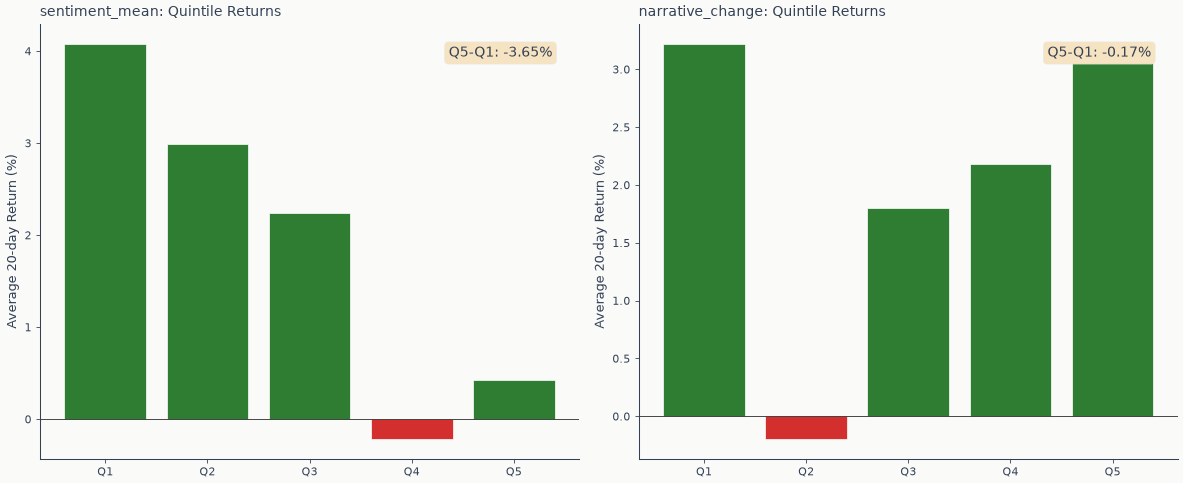

In [22]:
# Quintile analysis for key signals
key_signals = ["sentiment_mean", "narrative_change"]
fig, axes = plt.subplots(1, len(key_signals), figsize=(6 * len(key_signals), 5))
if len(key_signals) == 1:
    axes = [axes]

for i, sig in enumerate(key_signals):
    ax = axes[i]
    q_df = quintile_analysis(eval_df, sig, "fwd_20d")

    if q_df.height > 0:
        quintiles = q_df["quintile"].to_list()
        returns = q_df["avg_return"].to_numpy()
        colors = ["#d32f2f" if r < 0 else "#2e7d32" for r in returns]

        ax.bar(range(len(quintiles)), returns * 100, color=colors, edgecolor="white")
        ax.set_xticks(range(len(quintiles)))
        ax.set_xticklabels(quintiles)
        ax.set_ylabel("Average 20-day Return (%)")
        ax.set_title(f"{sig}: Quintile Returns")
        ax.axhline(0, color="black", linewidth=0.5)

        # Long-short spread
        if len(returns) >= 2:
            spread = returns[-1] - returns[0]
            ax.text(
                0.95,
                0.95,
                f"Q5-Q1: {spread * 100:.2f}%",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=10,
                bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
            )
    else:
        ax.text(0.5, 0.5, "Insufficient data", transform=ax.transAxes, ha="center")
        ax.set_title(f"{sig}: Quintile Returns")

fig.tight_layout()
fig.show()

## 7. Save Signals

Save the computed signals for potential downstream use.

In [23]:
# Save evaluation dataset
eval_df.write_parquet(OUTPUT_DIR / "filing_signals.parquet")
print(f"Saved {len(eval_df):,} signal observations to {OUTPUT_DIR / 'filing_signals.parquet'}")

# Save IC summary
if len(ic_summary) > 0:
    ic_summary.write_parquet(OUTPUT_DIR / "ic_summary.parquet")
    print(f"Saved IC summary to {OUTPUT_DIR / 'ic_summary.parquet'}")

Saved 744 signal observations to 10_text_feature_engineering/output/filing_signals/filing_signals.parquet
Saved IC summary to 10_text_feature_engineering/output/filing_signals/ic_summary.parquet


## Key Takeaways

1. **SEC filings provide dense, structured text** with natural PIT anchoring via filing dates.
   MD&A sections average ~6,000 words per quarter — far richer than news headlines.

2. **Chunking is essential for transformer models** that have 512-token limits.
   Mean-pooled paragraph-level scores approximate full-document analysis.

3. **Two complementary signal types emerge from the same text**:
   - *Sentiment* captures directional management tone (optimistic vs cautious)
   - *Narrative change* captures information novelty (quarter-over-quarter semantic shift)

4. **Signal evaluation is screening-grade**. The pooled Spearman ICs above
   are reported with cluster bootstrap (cluster=symbol) CIs and p-values
   rather than the i.i.d. t-stat formula, because the pooled sample
   contains multiple filings per firm and overlapping forward-return
   windows. Treat the magnitudes as a screen; chapter-headline inference
   uses HAC on per-date cross-sectional IC series (NB07, NB08), which
   requires adequate breadth per date.

5. **Filing signals complement headline signals** (NB07). News captures market reaction
   speed; filings capture management's own assessment of financial condition.

**Next**: See NB07/08 for news-based signal construction and evaluation.
**Book**: Section 10.5 discusses the full pre-train → adapt → fine-tune cascade
and signal validation protocol for production deployment.

In [24]:
print("\n" + "=" * 70)
print("NOTEBOOK COMPLETE: SEC Filing Text Signals")
print("=" * 70)
print(f"""
Signals computed:
  - sentiment_mean: FinBERT paragraph-level sentiment (mean across chunks)
  - sentiment_std: Within-filing sentiment dispersion
  - sentiment_pos_pct / sentiment_neg_pct: Fraction of positive/negative chunks
  - narrative_change: Cosine distance to prior quarter's MD&A embedding

Evaluation dataset: {len(eval_df):,} filing-date observations
Symbols: {eval_df["symbol"].n_unique()}
Date range: {eval_df["filing_date"].min()} to {eval_df["filing_date"].max()}
Output: {OUTPUT_DIR}
""")


NOTEBOOK COMPLETE: SEC Filing Text Signals

Signals computed:
  - sentiment_mean: FinBERT paragraph-level sentiment (mean across chunks)
  - sentiment_std: Within-filing sentiment dispersion
  - sentiment_pos_pct / sentiment_neg_pct: Fraction of positive/negative chunks
  - narrative_change: Cosine distance to prior quarter's MD&A embedding

Evaluation dataset: 744 filing-date observations
Symbols: 50
Date range: 2017-01-09 to 2021-12-02
Output: 10_text_feature_engineering/output/filing_signals

